# Chapter 4 - Policy Gradient Methods

In [1]:
import numpy as np
import torch
import gymnasium as gym
from matplotlib import pyplot as plt

##### Listing 4.1 - Listing the OpenAI Gym environments

In [2]:
from gymnasium import envs

env_names = list(envs.registry.keys())

print(f"Total envs: {len(env_names)}")
print(env_names[:5])

Total envs: 63
['CartPole-v0', 'CartPole-v1', 'MountainCar-v0', 'MountainCarContinuous-v0', 'Pendulum-v1']


##### Listing 4.2 - Creating an environment in OpenAI Gym

In [3]:
env = gym.make("CartPole-v1")

In [4]:
def print_state(_state):
    s_str = (
        f"Cart position: {_state[0]}\n"
        f"Cart velocity: {_state[1]}\n"
        f"Pole angle:    {_state[2]}\n"
        f"Pole velocity: {_state[3]}"
    )
    print(s_str)

##### Listing 4.3 - Taking an action in CartPole

In [5]:
state1, info = env.reset()
print_state(state1)
action = env.action_space.sample()
print("A:", action)
state2, reward, terminated, truncated, info = env.step(action)
print_state(state2)
print("Reward:", reward)

Cart position: -0.017627714201807976
Cart velocity: -0.032016851007938385
Pole angle:    -0.04900936782360077
Pole velocity: 0.019934192299842834
A: 0
Cart position: -0.018268050625920296
Cart velocity: -0.22640293836593628
Pole angle:    -0.04861068353056908
Pole velocity: 0.296760231256485
Reward: 1.0


##### Listing 4.4 - Setting up the policy network

In [6]:
l1 = 4  # A
l2 = 150
l3 = 2  # B

model = torch.nn.Sequential(
    torch.nn.Linear(l1, l2),
    torch.nn.LeakyReLU(),
    torch.nn.Linear(l2, l3),
    torch.nn.Softmax(dim=-1),  # C
)

learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# A Input data is length 4
# B Output is a 2-length vector for the Left and the Right actions
# C Output is a softmax probability distribution over actions

##### Listing 4.5 - Using the policy network to sample an action

In [7]:
state1 = env.reset()
pred = model(torch.from_numpy(state1[0]))  # G
action = np.random.choice(np.array([0, 1]), p=pred.data.numpy())  # H
state2, reward, terminated, truncated, info = env.step(action)  # I

# G Call policy network model to produce predicted action probabilities
# H Sample an action from the probability distribution produced by the policy network
# I Take the action, receive new state and reward. The info variable is produced by the environment but is irrelevant

##### Listing 4.6 - Computing the discounted rewards

In [8]:
def discount_rewards(rewards, gamma=0.99):
    lenr = len(rewards)
    disc_return = torch.pow(gamma, torch.arange(lenr).float()) * rewards  # A
    disc_return /= disc_return.max()  # B
    return disc_return


# A Compute exponentially decaying rewards
# B Normalize the rewards to be within the [0,1] interval to improve numerical stability

discount_rewards(torch.tensor([5, 4, 3, 2, 1]), gamma=0.99)

tensor([1.0000, 0.7920, 0.5881, 0.3881, 0.1921])

##### Listing 4.7 - Defining the loss function

In [9]:
def loss_fn(preds, r):  # A
    return -1 * torch.sum(r * torch.log(preds))  # B


# A The loss function expects an array of action probabilities for the actions that were taken and the discounted rewards.
# B It computes the log of the probabilities, multiplies by the discounted rewards, sums them all and flips the sign.

##### Listing 4.8 - The REINFORCE training loop

In [10]:
MAX_DUR = 200
MAX_EPISODES = 500
gamma = 0.99
score = []  # A
for episode in range(MAX_EPISODES):
    state1 = env.reset()[0]
    transitions = []  # B

    for t in range(MAX_DUR):  # C
        act_prob = model(torch.from_numpy(state1).float())  # D
        action = np.random.choice(np.array([0, 1]), p=act_prob.data.numpy())  # E
        state2, _, terminated, truncated, _ = env.step(action)  # F
        transitions.append((state1, action, t + 1))  # G
        if terminated or truncated:  # H, done
            break
        state1 = state2

    ep_len = len(transitions)  # I
    score.append(ep_len)
    reward_batch = torch.Tensor([r for (s, a, r) in transitions]).flip(dims=(0,))  # J
    disc_returns = discount_rewards(reward_batch)  # K
    state_batch = torch.from_numpy(np.stack([s for (s, a, r) in transitions]))  # L
    action_batch = torch.Tensor([a for (s, a, r) in transitions])  # M
    pred_batch = model(state_batch)  # N
    prob_batch = pred_batch.gather(
        dim=1, index=action_batch.long().view(-1, 1)
    ).squeeze()  # O
    loss = loss_fn(prob_batch, disc_returns)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# A List to keep track of the episode length over training time
# B List of state, action, rewards (but we ignore the reward)
# C While in episode
# D Get the action probabilities
# E Select an action stochastically
# F Take the action in the environment
# G Store this transition
# H If game is lost, break out of the loop
# I Store the episode length
# J Collect all the rewards in the episode in a single tensor
# K Compute the discounted version of the rewards
# L Collect the states in the episode in a single tensor
# M Collect the actions in the episode in a single tensor
# N Re-compute the action probabilities for all the states in the episode
# O Subset the action-probabilities associated with the actions that were actually taken

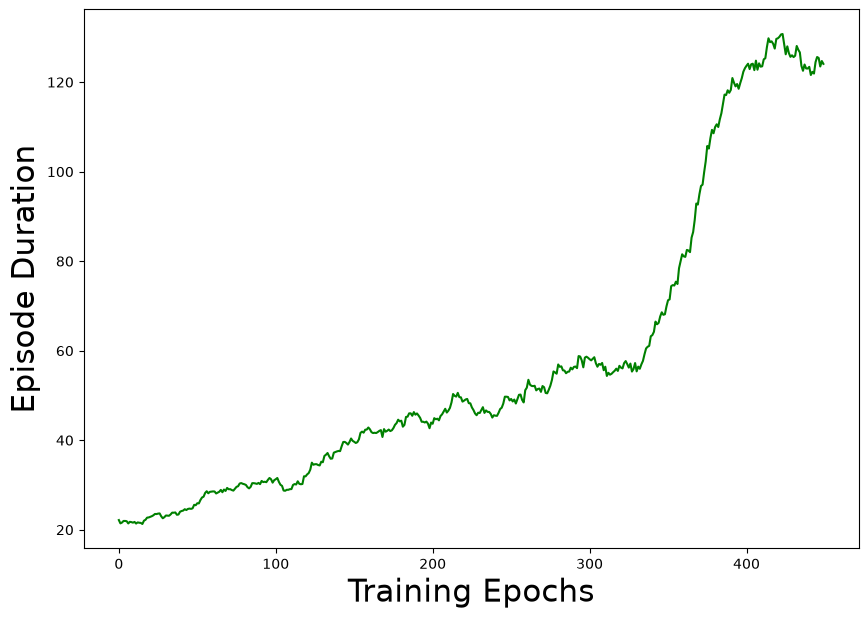

In [11]:
def running_mean(x, N=50):
    kernel = np.ones(N)
    conv_len = x.shape[0] - N
    y = np.zeros(conv_len)
    for i in range(conv_len):
        y[i] = kernel @ x[i : i + N]
        y[i] /= N
    return y


score = np.array(score)
avg_score = running_mean(score, 50)

plt.figure(figsize=(10, 7))
plt.ylabel("Episode Duration", fontsize=22)
plt.xlabel("Training Epochs", fontsize=22)
plt.plot(avg_score, color="green")

##### Listing 4.9

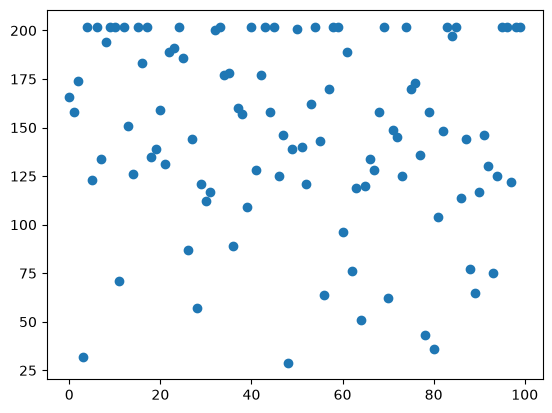

In [12]:
score = []
games = 100
state1 = env.reset()[0]
for i in range(games):
    done = False
    t = 0
    while not done:
        pred = model(torch.from_numpy(state1).float())
        action = np.random.choice(np.array([0, 1]), p=pred.data.numpy())
        state2, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated or t > MAX_DUR
        state1 = state2
        t += 1
    state1, _ = env.reset()
    score.append(t)

score = np.array(score)
plt.scatter(np.arange(score.shape[0]), score)

##### Visual Gameplay

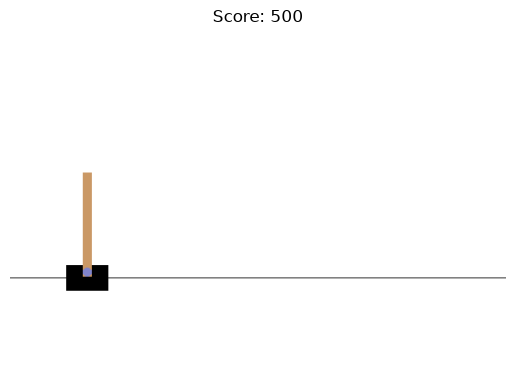

In [13]:
import time
from IPython.display import clear_output

env = gym.make("CartPole-v1", render_mode="rgb_array")

state1, _ = env.reset()

reward = 0
done = False
while not done:
    pred = model(torch.from_numpy(state1).float())
    action = np.argmax(pred.data.numpy())
    state2, _, terminated, truncated, info = env.step(action)
    state1 = state2

    done = terminated or truncated
    reward += 1

    frame = env.render()
    clear_output(wait=True)
    plt.imshow(frame)
    plt.title(f"Score: {reward}")
    plt.axis("off")
    plt.show()

    time.sleep(0.1)


env.close()